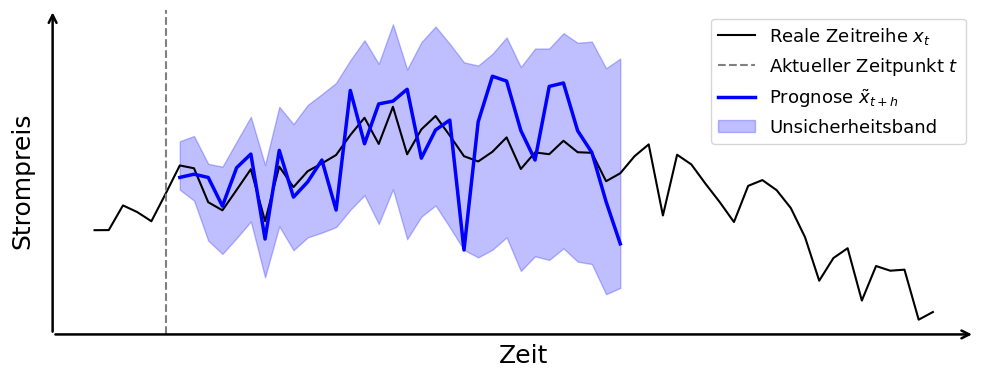

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_forecast_uncertainty(x, t0, H, sigma0, sigmaH,
                              schedule="sqrt", seed=42):

    x = np.asarray(x, dtype=float)
    assert 0 <= t0 < len(x)
    assert t0 + H < len(x), "Nicht genügend Zukunftswerte verfügbar"

    # Horizonabhängige Standardabweichung
    h = np.arange(1, H + 1, dtype=float)
    frac = h / H

    if schedule == "linear":
        sigma = sigma0 + (sigmaH - sigma0) * frac
    elif schedule == "sqrt":
        sigma = sigma0 + (sigmaH - sigma0) * np.sqrt(frac)
    else:
        raise ValueError("schedule muss 'linear' oder 'sqrt' sein")

    rng = np.random.default_rng(seed)
    eps = rng.normal(0.0, 1.0, size=H)

    # Prognose bleibt garantiert innerhalb ±2σ
    eps = np.clip(eps, -2.0, 2.0)

    tf = t0 + h.astype(int)
    true_future = x[tf]

    # Prognose mit begrenztem Fehler
    forecast = true_future + sigma * eps

    # Unsicherheitsband um reale Zukunft
    upper = true_future + 2 * sigma
    lower = true_future - 2 * sigma

    t = np.arange(len(x))

    # Größere Schrift
    plt.rcParams.update({
        "font.size": 14
    })

    fig, ax = plt.subplots(figsize=(10, 4))

    # Daten zeichnen
    ax.plot(t, x, color="black", linewidth=1.5,
            label="Reale Zeitreihe $x_t$")
    ax.axvline(t0, linestyle="--", color="gray",
               label="Aktueller Zeitpunkt $t$")
    ax.plot(tf, forecast, linewidth=2.5, color="blue",
            label="Prognose $\\tilde{x}_{t+h}$")
    ax.fill_between(tf, lower, upper,
                    color="blue", alpha=0.25,
                    label="Unsicherheitsband")

    # Standardachsen entfernen
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])

    # Pfeilachsen
    y_min, y_max = ax.get_ylim()
    x_min, x_max = ax.get_xlim()

    ax.annotate("",
                xy=(x_max, y_min),
                xytext=(x_min, y_min),
                arrowprops=dict(arrowstyle="->", linewidth=1.8))

    ax.annotate("",
                xy=(x_min, y_max),
                xytext=(x_min, y_min),
                arrowprops=dict(arrowstyle="->", linewidth=1.8))

    # Beschriftung
    ax.text(x_max - 30, y_min - 2,
            "Zeit",
            ha="right", va="top",
            fontsize=18)

    ax.text(x_min - 3, y_max -50,
            "Strompreis",
            ha="left", va="bottom",
            rotation=90,
            fontsize=18)

    ax.legend(loc="upper right", fontsize=13)

    plt.tight_layout()
    plt.show()


# Beispiel
N = 60
t = np.arange(N)
x = 100 + 20*np.sin(2*np.pi*t/96) + \
    5*np.random.default_rng(0).normal(size=N)

plot_forecast_uncertainty(
    x=x,
    t0=5,
    H=32,
    sigma0=0.5,
    sigmaH=12.0,
    schedule="sqrt",
    seed=123
)
